In [41]:
from pylib.setup import *
setup_notebook()

from pylib.assumptions import demand, solar_tech, wind_tech, battery, gas_tech, GAS_MIN_LOAD, smr_tech, SMR_DOWNTIME, GRID_TARIFF_BUY, grid_connect_annual
from pylib.model import GridSupply, VESupply, VEGasSupply, KKSupply

USE_GAS = True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load profile and exports — VE scenario

Shows hour by hour how the datacenter's 1 GW demand is met in the VE scenario.
Each hour is decomposed into four sources: solar, wind, battery (discharge) and grid import.
Below zero, surplus production exported at spot price is shown, capped at the grid connection capacity $(1-x) \cdot P = 500$ MW.

*`1. input data`*

*Loads the three 8,760-row input files and normalises to capacity factors and EUR/MWh.*

In [42]:
# 1. inputdata
pat           = pathlib.Path('variation_patterns')
_solar_cap_mw = 4_955.5428
_wind_cap_mw  = 4_878.483

solar_cf = np.loadtxt(pat / 'PV_VE_2025_2026.txt') / _solar_cap_mw
wind_cf  = np.loadtxt(pat / 'WL_VE_2025_2026.txt') / _wind_cap_mw
prices   = np.loadtxt(pat / 'wp_2025_2026.txt')    / 7.46

print(f'solar_cf  mean={solar_cf.mean():.3f}  max={solar_cf.max():.3f}')
print(f'wind_cf   mean={wind_cf.mean():.3f}  max={wind_cf.max():.3f}')
print(f'prices    mean={prices.mean():.1f}  min={prices.min():.1f}  max={prices.max():.1f} EUR/MWh')

solar_cf  mean=0.103  max=0.750
wind_cf   mean=0.229  max=0.816
prices    mean=81.6  min=-30.7  max=583.5 EUR/MWh


*`2. build model and load solution`*

*Initialises model layers, loads capacities from `runs/ve_solution.json`, and loads the saved LP dispatch arrays from `runs/ve_lp_arrays.npz` — no optimisation or LP re-solve required. Run `2_model.ipynb` to regenerate both files.*

In [43]:
# 2. byg model og indlæs løsning
grid = GridSupply(prices, demand)

if USE_GAS:
    ve = VEGasSupply(solar_cf, wind_cf, solar_tech, wind_tech, battery, gas_tech,
                     demand, prices=prices, storage_hours=4,
                     buy_tariff=GRID_TARIFF_BUY,
                     grid_connect_annual=grid_connect_annual(demand.grid_cap_mw),
                     min_load=GAS_MIN_LOAD)
    ve.load_lp_arrays('runs/vegas_lp_arrays.npz')
    lp = ve.lp_detail()
    print(f'  Solkraft    : {lp["c_solar"]:,.0f} MW')
    print(f'  Vindkraft   : {lp["c_wind"]:,.0f} MW')
    print(f'  Batteri     : {lp["batt_power"]:,.0f} MW / {lp["batt_energy"]:,.0f} MWh')
    print(f'  Gasturbine  : {lp["c_gas"]:,.0f} MW  (min load {GAS_MIN_LOAD:.0%})')
else:
    ve = VESupply(solar_cf, wind_cf, solar_tech, wind_tech, battery, demand, prices=prices)
    ve.load()
    ve.load_lp_arrays()
    c_solar, c_wind, batt_power, batt_energy = ve.solution
    print(f'  Solkraft : {c_solar:,.0f} MW')
    print(f'  Vindkraft: {c_wind:,.0f} MW')
    print(f'  Batteri  : {batt_power:,.0f} MW / {batt_energy:,.0f} MWh')

  Solkraft    : 1,000 MW
  Vindkraft   : 500 MW
  Batteri     : 401 MW / 1,602 MWh
  Gasturbine  : 575 MW  (min load 40%)


*`3. helper functions`*

*`dispatch_detail`, `aggregate_dispatch` and `plot_dispatch` are loaded from `pylib/ve_dispatch.py` via `setup_notebook()`.*

In [44]:
# 3. hjælpefunktioner
# dispatch_detail, aggregate_dispatch, plot_dispatch injected by setup_notebook()

# ── compute ───────────────────────────────────────────────────────────────────
dates = pd.date_range('2025-01-01', periods=8760, freq='h')
d     = dispatch_detail(ve, solar_cf, wind_cf)

print(f"Solkraft til forbrug  : {d['pv'].sum()/1e6:.2f} TWh/år")
print(f"Vindkraft til forbrug : {d['wind'].sum()/1e6:.2f} TWh/år")
if 'gas' in d:
    print(f"Gas til forbrug       : {d['gas'].sum()/1e6:.2f} TWh/år")
print(f"Batteri til forbrug   : {d['battery'].sum()/1e6:.2f} TWh/år")
print(f"Netimport             : {d['grid'].sum()/1e6:.2f} TWh/år")
print(f"Eksport               : {d['exported'].sum()/1e6:.2f} TWh/år")

Solkraft til forbrug  : 0.66 TWh/år
Vindkraft til forbrug : 0.74 TWh/år
Gas til forbrug       : 3.32 TWh/år
Batteri til forbrug   : 0.44 TWh/år
Netimport             : 3.60 TWh/år
Eksport               : 0.05 TWh/år


# Hourly dispatch — demand and exports

For each of the year's 8,760 hours, the 1 GW demand is decomposed into solar, wind, battery and grid import (above zero). Grid exports at spot price are shown below zero.

*`4. hourly plot`*

*Stacked area plot across the year's 8,760 hours with monthly labels on the x-axis; exports shown as negative area.*

In [45]:
# # 4. timeplot
# plot_dispatch(d, dates, ylabel='MW', save_path='figures/3_ve_dispatch_hourly.png')

# Aggregated profiles

Same breakdown as the hourly plot, averaged to day, week and month to highlight seasonal patterns without hourly noise.

*`5. daily average`*

*Mean MW across each of the 365 days.*

In [46]:
# # 5. daglig aggregering
# d_day, idx_day = aggregate_dispatch(d, dates, 'D')
# plot_dispatch(d_day, idx_day, ylabel='MW',
#               title="Vindkraft dækker vinteren; sol og eksport dominerer sommeret",
#               subtitle="Daglig gennemsnitlig produktion og nethandel, VE-scenariet, 2025–26 (x = 50 %)",
#               save_path='figures/3_ve_dispatch_daily.png')

*`6. weekly average`*

*Mean MW across each of the 52 weeks.*

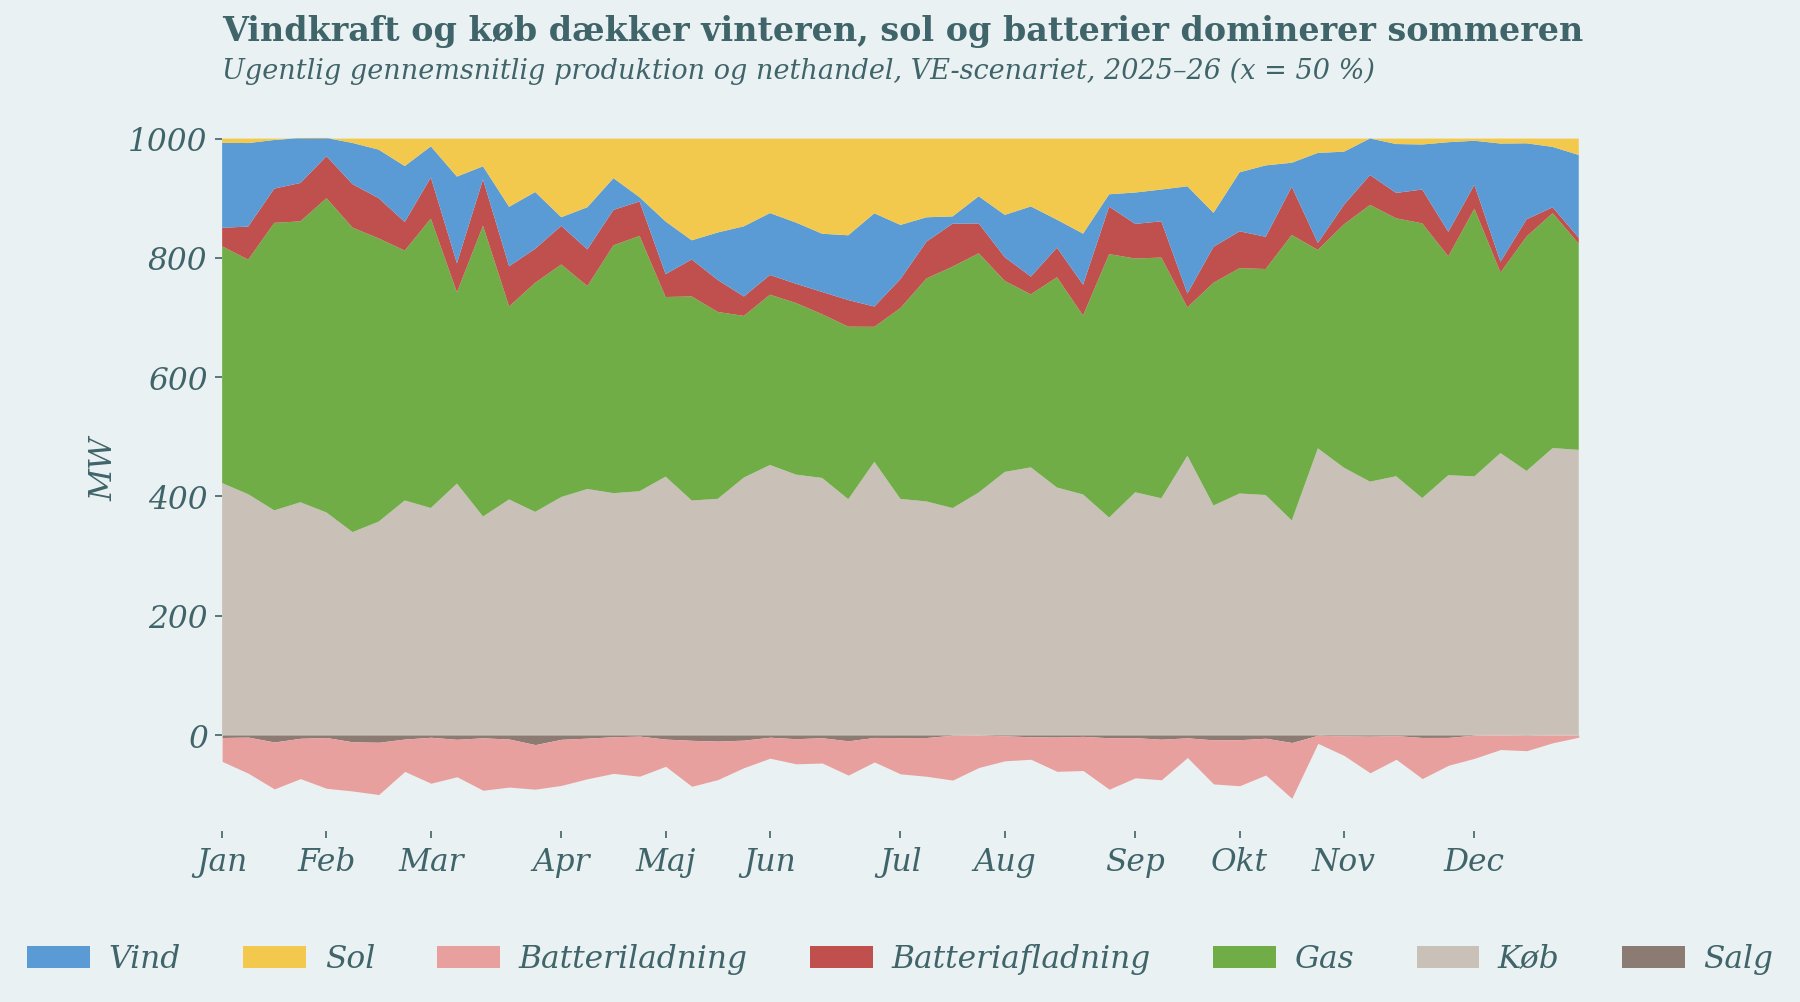

(<Figure size 1800x1050 with 1 Axes>,
 <Axes: title={'left': 'Vindkraft og køb dækker vinteren, sol og batterier dominerer sommeren'}, ylabel='MW'>)

In [47]:
# 6. ugentlig aggregering
d_week, idx_week = aggregate_dispatch(d, dates, 'W')
plot_dispatch(d_week, idx_week, ylabel='MW',
              title="Vindkraft og køb dækker vinteren, sol og batterier dominerer sommeren",
              subtitle="Ugentlig gennemsnitlig produktion og nethandel, VE-scenariet, 2025–26 (x = 50 %)",
              save_path='figures/3_ve_dispatch_weekly.png')

*`7. monthly average`*

*Mean MW across each of the 12 months.*

In [48]:
# # 7. månedlig aggregering
# d_month, idx_month = aggregate_dispatch(d, dates, 'ME')
# plot_dispatch(d_month, idx_month, ylabel='MW',
#               save_path='figures/3_ve_dispatch_monthly.png')

# Battery flows and state of charge

Weekly mean MW flows (right axis): charge above zero in amber, discharge to datacenter below zero in red, discharge to grid below zero in grey (zero in current model). Weekly mean state of charge in MWh on the left axis (blue fill).

*`8. battery figure`*

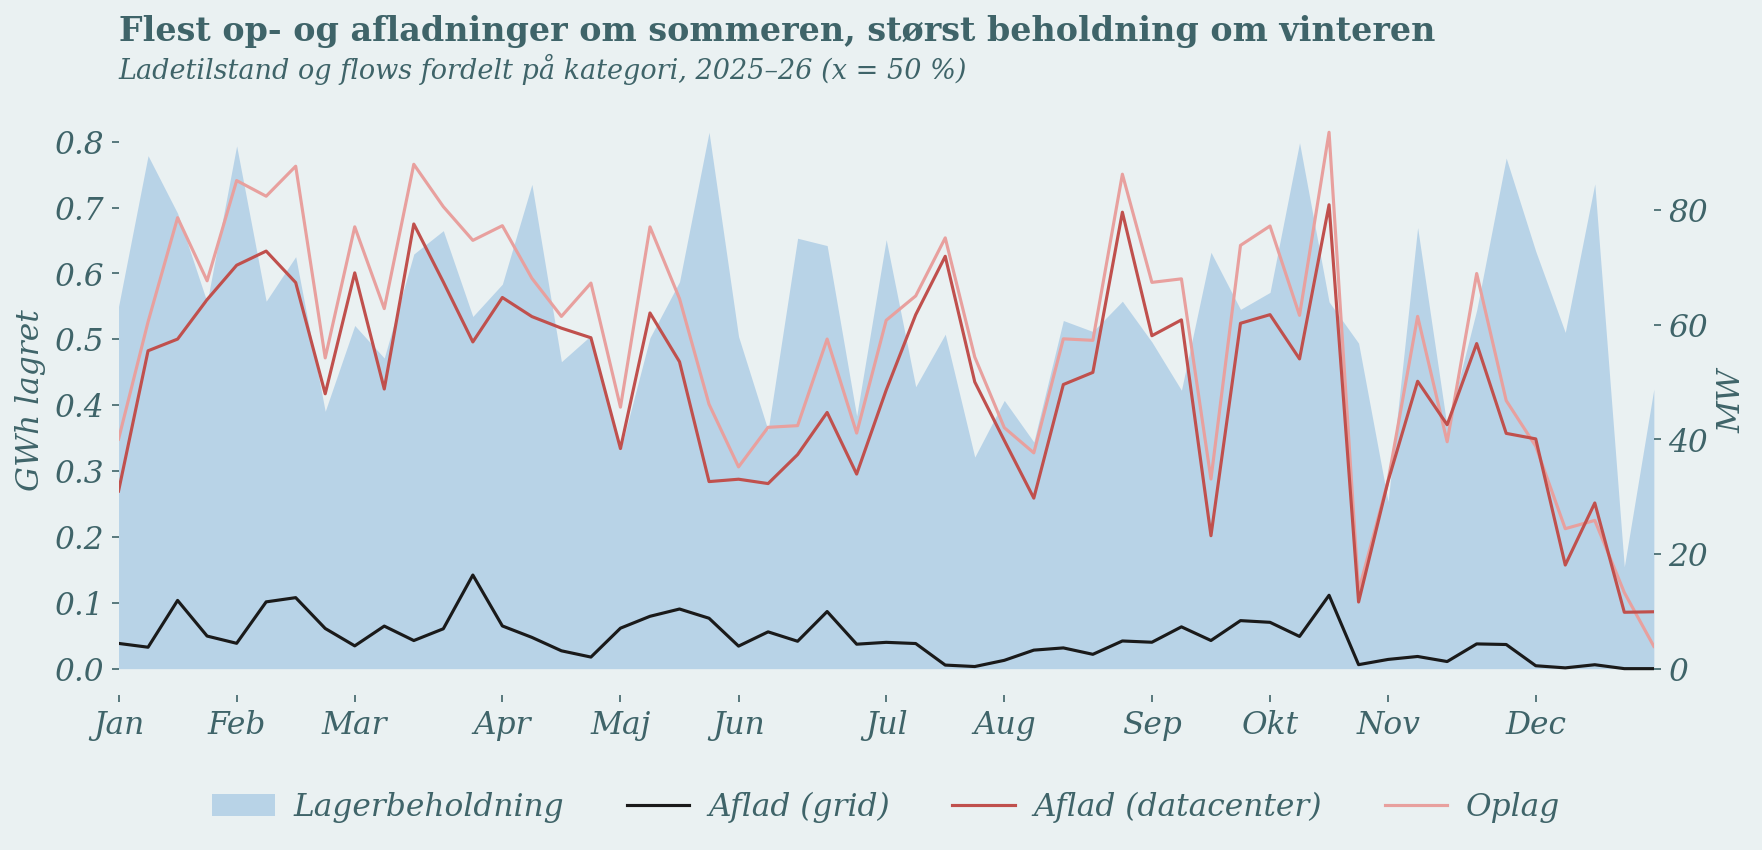

(<Figure size 1800x900 with 2 Axes>,
 (<Axes: title={'left': 'Flest op- og afladninger om sommeren, størst beholdning om vinteren'}, ylabel='GWh lagret'>,
  <Axes: ylabel='MW'>))

In [49]:
# 8. battery figure
batt          = battery_detail(ve, solar_cf, wind_cf)
batt_week, idx_week = aggregate_dispatch(batt, dates, 'W')
plot_battery(batt_week, idx_week,
             title="Flest op- og afladninger om sommeren, størst beholdning om vinteren",
             subtitle="Ladetilstand og flows fordelt på kategori, 2025–26 (x = 50 %)",
             save_path='figures/3_ve_battery.png')

# Curtailment — weekly average

The LP solves directly for `curtail_pv[t]` and `curtail_wl[t]` as separate variables. Wind carries a variable O&M of 1.98 €/MWh charged on dispatched generation — curtailing wind therefore saves 1.98 €/MWh in the objective. The LP always curtails wind before solar.

*`11. curtailment — weekly average`*

*Weekly mean curtailment in MW, split between wind and solar by the LP's own dispatch.*

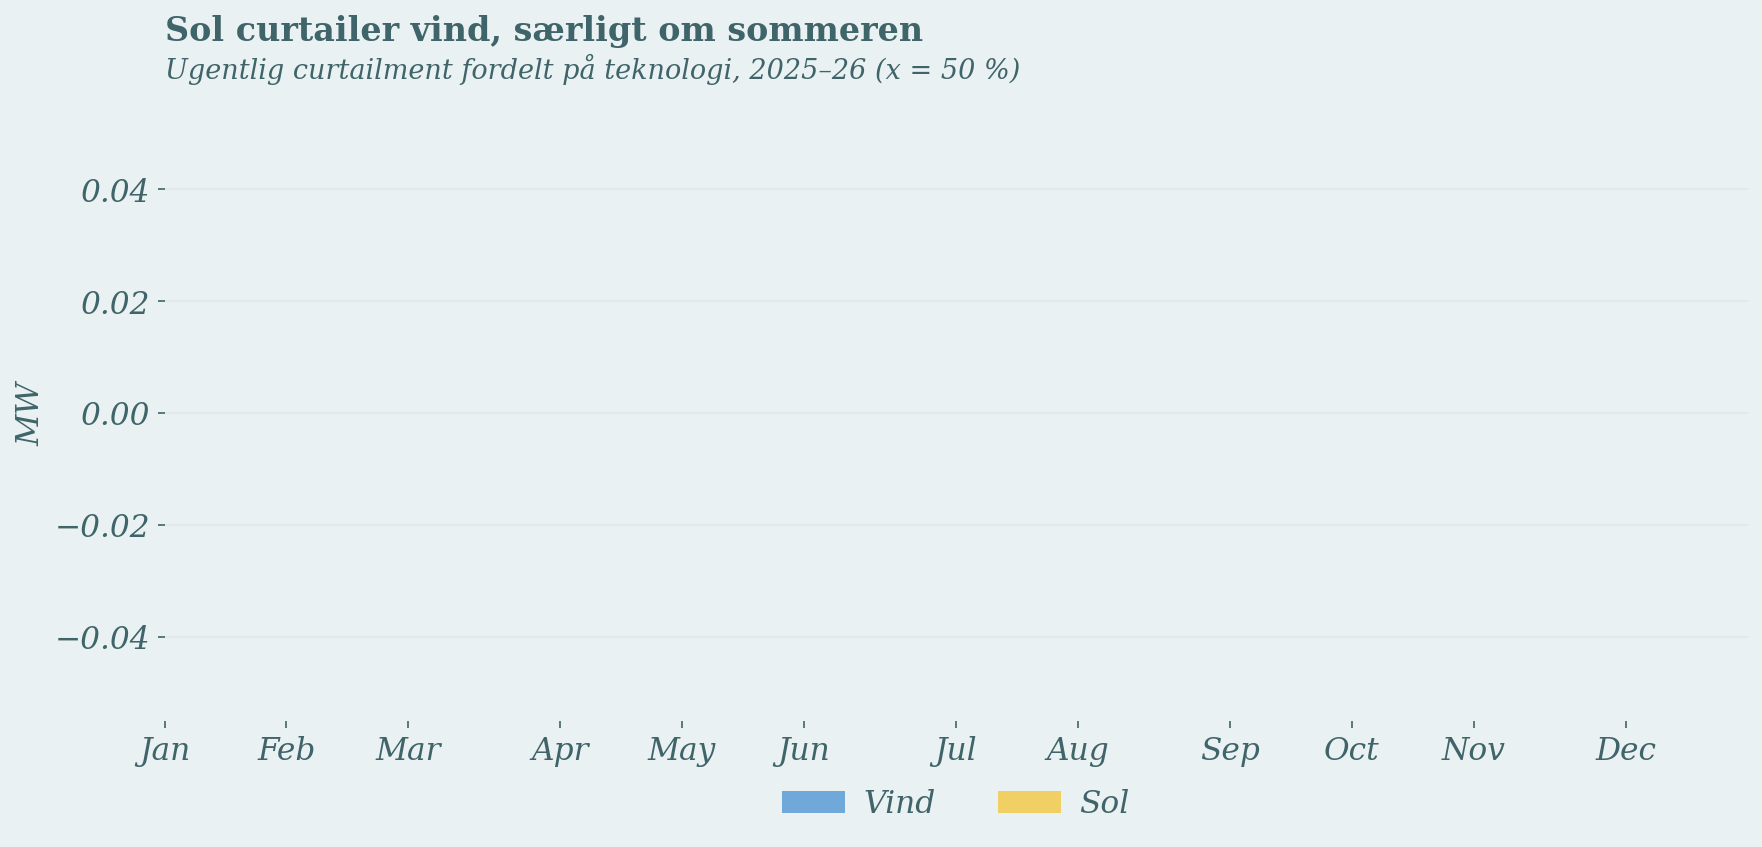

In [50]:
# 11. curtailment — weekly average
lp      = ve.lp_detail()
curt_pv = lp['curtail_pv']
curt_wl = lp['curtail_wl']

curt_week, idx_w = aggregate_dispatch({'pv': curt_pv, 'wind': curt_wl}, dates, 'W')

ticks, labs = [], []
for m in range(1, 13):
    pos = np.where(idx_w.month == m)[0]
    if not len(pos):
        continue
    gaps = np.where(np.diff(pos) > 1)[0]
    if len(gaps):
        pos = pos[:gaps[0] + 1]
    ticks.append(pos[0])
    labs.append(MAANED_EN[m - 1])

x = np.arange(len(idx_w))
C = DISPATCH_COLORS
fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(x, curt_week['wind'], curt_week['pv'],
             labels=['Vind', 'Sol'],
             colors=[C['wind'], C['pv']], alpha=0.85, linewidth=0)

ax.set_xlim(0, len(x) - 1)
ax.set_xticks(ticks)
ax.set_xticklabels(labs)
ax.set_ylabel('MW')
ax.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.2))
ax.grid(linewidth=1., alpha=0.05, color='#3F6469', axis='y')

fig_title(ax,
          "Sol curtailer vind, særligt om sommeren",
          "Ugentlig curtailment fordelt på teknologi, 2025–26 (x = 50 %)")
plt.tight_layout()
fig.savefig('figures/3_ve_curtailment_weekly.png', dpi=300)
plt.show()

# Nuclear profile — planned outage

The SMR runs at full capacity (1,000 MW) for $1 - d$ of the year, where $d = 10\%$ is the planned maintenance fraction. The downtime block is placed contiguously at the cheapest consecutive 876 hours, minimising grid purchase cost.

*`9. build KK`*

*Constructs `KKSupply` from the loaded price series and prints the optimal outage window.*

In [51]:
# 9. build KK
kk = KKSupply(smr_tech, demand, prices, downtime_fraction=SMR_DOWNTIME,
              buy_tariff=GRID_TARIFF_BUY,
              grid_connect_annual=grid_connect_annual(demand.demand_mw))

outage   = kk._outage_mask()
kk_disp  = kk.dispatch()

start_dt = dates[outage][0]
end_dt   = dates[outage][-1]
print(f'Outage: {start_dt.strftime("%d. %b")} – {end_dt.strftime("%d. %b")}  ({outage.sum()} h)')

Outage: 20. May – 25. Jun  (876 h)


*`10. hourly profile`*

*Stacked area at hourly resolution: nuclear on-site production (blue) and grid import during the outage window (grey).*

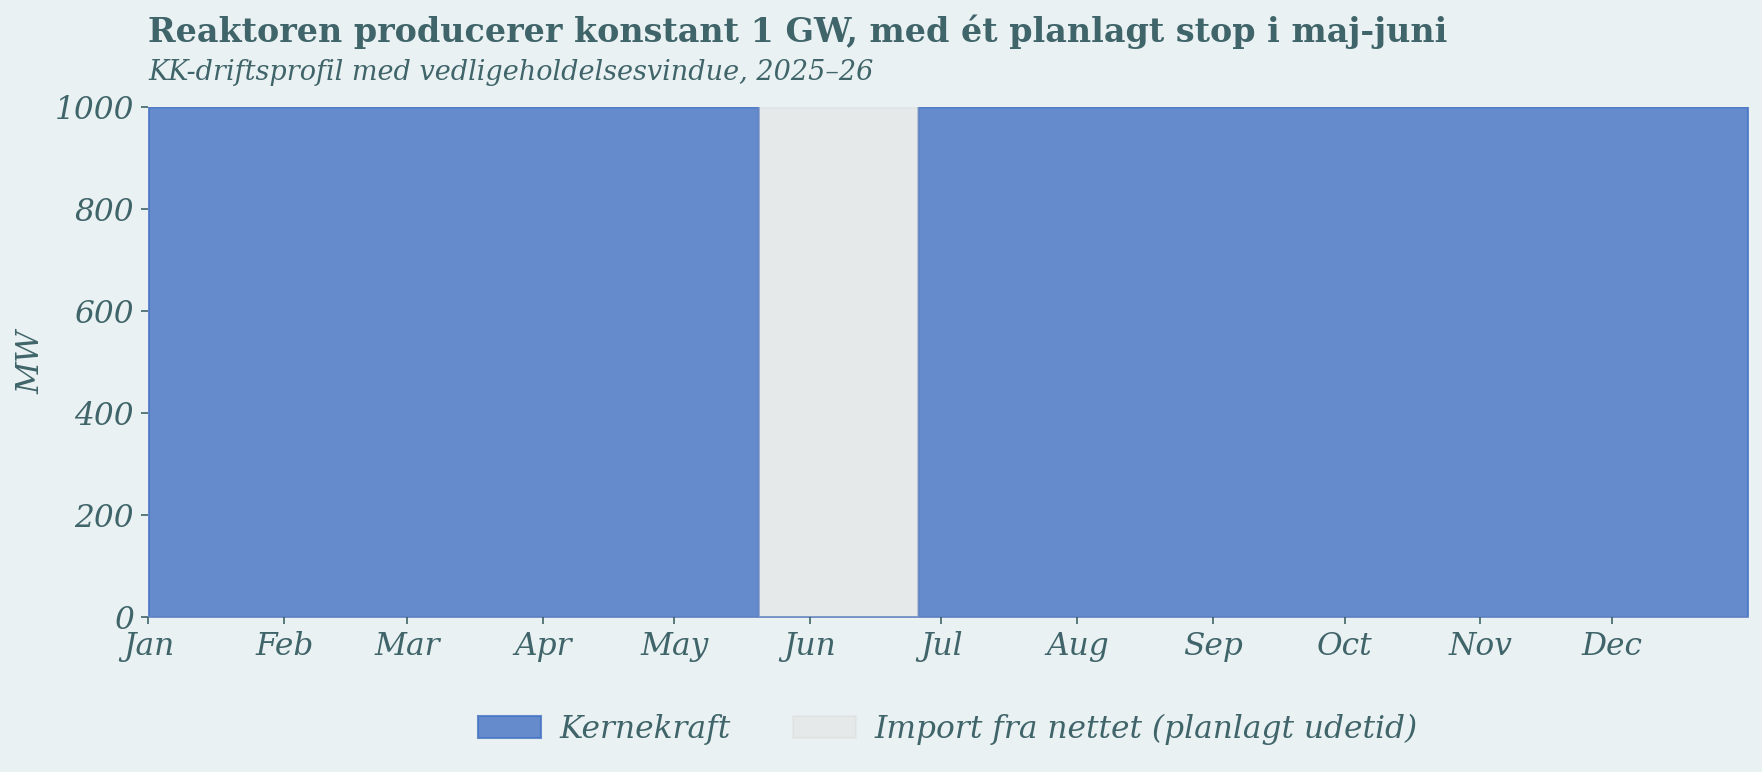

In [52]:
# 10. hourly profile
C = DISPATCH_COLORS

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(dates, kk_disp,
                step='pre', color=C['nuclear'], alpha=0.8,
                label='Kernekraft')
ax.fill_between(dates, np.where(outage, demand.demand_mw, 0.0),
                step='pre', color=C['grid'], alpha=0.15,
                label='Import fra nettet (planlagt udetid)')

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(dates[0], dates[-1])
ax.set_ylim(0, 1_000)
ax.set_ylabel('MW')
ax.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.3))

fig.tight_layout()
fig_title(ax,
          "Reaktoren producerer konstant 1 GW, med ét planlagt stop i maj-juni",
          "KK-driftsprofil med vedligeholdelsesvindue, 2025–26")
fig.savefig('figures/3_kk_profile.png', dpi=150)
plt.show()